HANDLING MISSING CATEGORICAL DATA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('housing.csv' , usecols = ['GarageQual', 'FireplaceQu', 'SalePrice'])

In [6]:
df


,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [7]:
df.isnull().mean()*100


FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [18]:
df['GarageQual'].isnull().sum()

np.int64(0)

Text(0, 0.5, 'No. of houses')

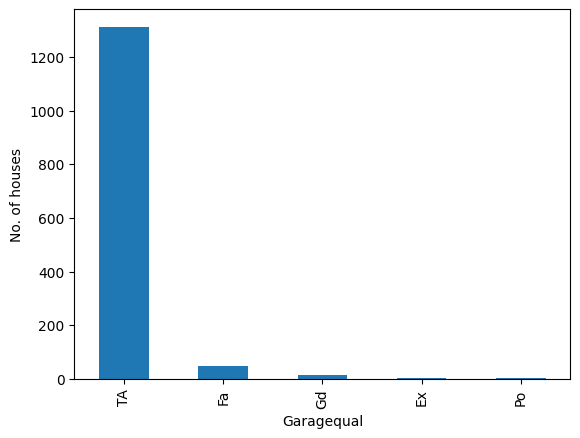

In [11]:
df['GarageQual'].value_counts().sort_values(ascending = False).plot(kind = 'bar')
plt.xlabel('Garagequal')
plt.ylabel('No. of houses')


In [12]:
df['GarageQual'].mode()


0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

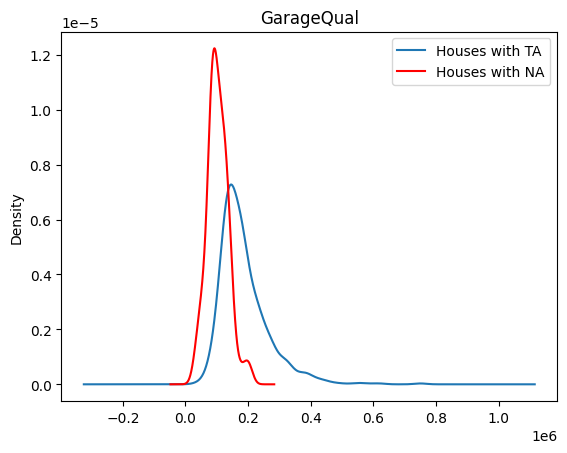

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind = 'kde', ax = ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind = 'kde' , ax = ax , color = 'red')


lines , labels = ax.get_legend_handles_labels()
labels= ['Houses with TA', 'Houses with NA']
ax.legend(lines , labels , loc = 'best')

plt.title('GarageQual')

In [14]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']


In [15]:
df['GarageQual'].fillna('TA', inplace = True)

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_5272/3144321422.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace = True)


<Axes: xlabel='GarageQual'>

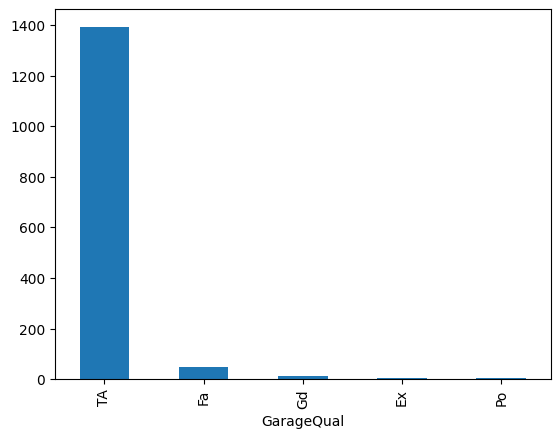

In [19]:
df['GarageQual'].value_counts().plot(kind = 'bar')


Text(0.5, 1.0, 'GarageQual')

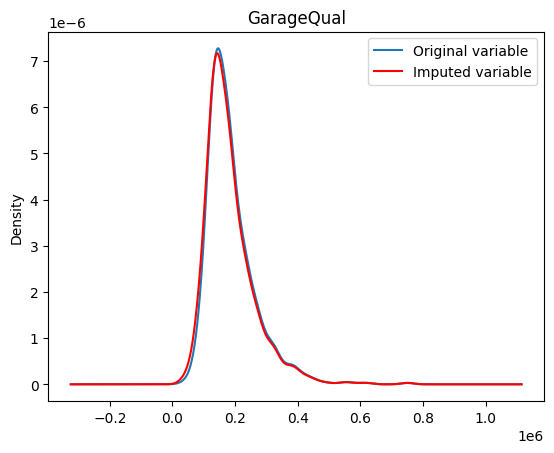

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind = 'kde', ax= ax)

df[df['GarageQual'] =='TA']['SalePrice'].plot(kind = 'kde' , ax = ax, color = 'red')


lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines , labels ,loc = 'best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

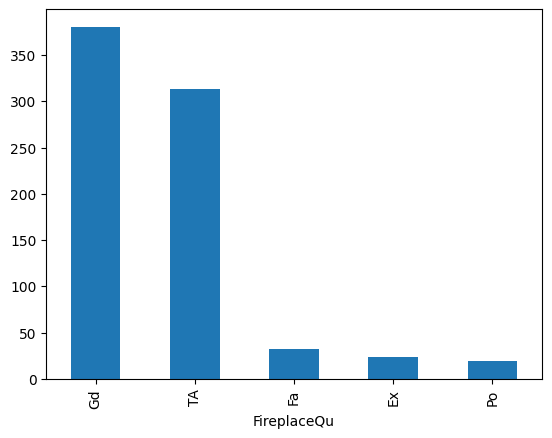

In [23]:
#filling missing values from fireplace column

df['FireplaceQu'].value_counts().plot(kind = 'bar')

In [24]:
df['FireplaceQu'].mode()


0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

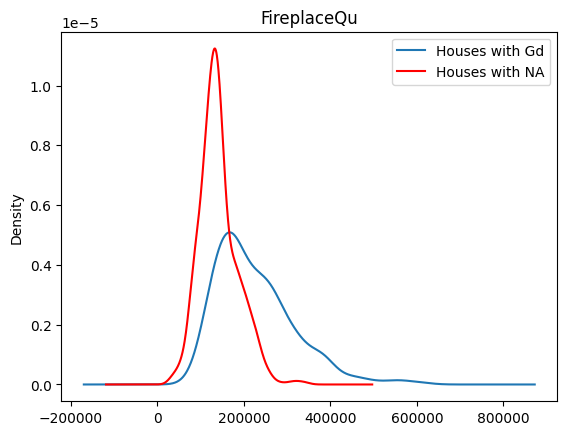

In [28]:
#comparision bw mode value and missing values

fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] =='Gd']['SalePrice'].plot(kind = 'kde', ax= ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind = 'kde' , color = 'red')

lines , labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines , labels , loc = 'best')


plt.title('FireplaceQu')

In [29]:
#imputation
temp = df[df['FireplaceQu']=='Gd']['SalePrice']



In [30]:
df['FireplaceQu'].fillna('Gd' , inplace = True)

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_5272/277906221.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd' , inplace = True)


<Axes: xlabel='FireplaceQu'>

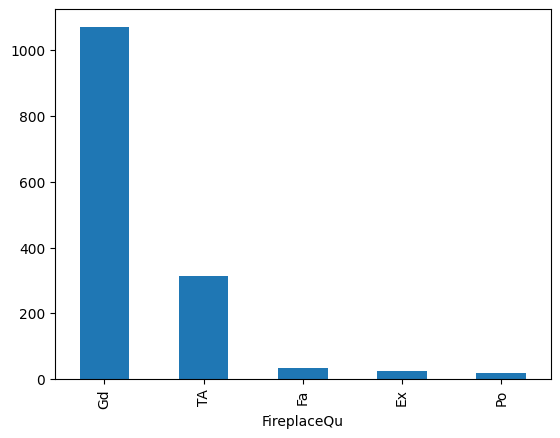

In [31]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')


Text(0.5, 1.0, 'FireplaceQu')

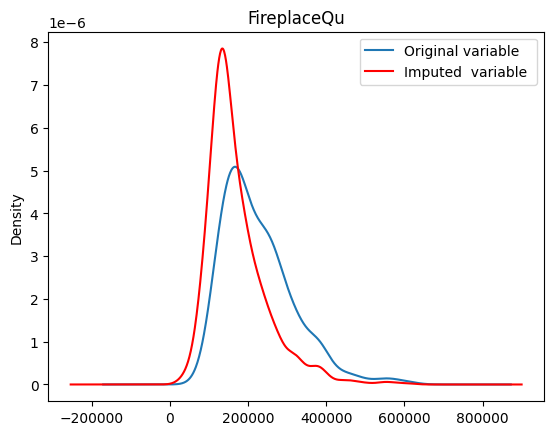

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind = 'kde', ax = ax )

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind = 'kde', ax = ax , color = 'red')

lines , labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed  variable ']
ax.legend(lines , labels , loc = 'best')

plt.title('FireplaceQu')

#not a fruitful outcome, wont prefer imputation here in this category

Using scikit learn to do the same

In [34]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop(columns = ['SalePrice']), df['SalePrice'], test_size = 0.2)

In [ ]:
from sklearn.impute import SimpleImputer


In [36]:
imputer = SimpleImputer(strategy = 'most_frequent')

In [37]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [38]:
imputer.statistics_


array(['Gd', 'TA'], dtype=object)